# Hernquist distribution
The aim of this notebook is to generate an unperturbed Hernquist distribution. We will then add two extra points which will simulate two black holes, to study the dynamical friction and their interaction.

The Henrquist profile is described by the follwing density distribution:

$$ \rho(r) = \frac{M}{2\pi}\frac{a}{r}\frac{1}{(r+a)^3} $$   
where $a$ is a scale radius. Note that for radii larger than $a$, the density goes as $r^{-4}$, at smaller radii it will instead go as r.

From the density distribution one can compute the mass distribution and the potential shape, assuming a spherical distribution. 

$$ M(R) = \int_0^R 4\pi r^2 \rho(r) dr  = \frac{M_{tot}R^2}{(R+a)^2}$$

$$ \phi_H (R) = -4\pi G\Bigl[\frac{1}{R} \int_0^R \rho(r) r^2 dr + \int_R^\infty \rho(r) r dr\Bigr] = - \frac{GM}{(R+a)}$$

In [1]:
#pip install scienceplots

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

import scienceplots
plt.style.use(['science', 'no-latex'])

## Initialization

In [3]:
n = 30000 #number of particles
a = 2.0 #scale radius
M = 1.0 #each particle has a mass = M/n in internal units
n_dim = 3

In [4]:
m = M/n
print (m)

3.3333333333333335e-05


In [5]:
def radius(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)
    
def v_circ(radius):
    return np.sqrt(M * radius) / (radius + a)

In [6]:
M_BH_1 = 0.01

x_1, y_1, z_1 = 3.0, 0.0, 0.0
r_1 = radius(x_1, y_1, z_1)

v_x1, v_y1, v_z1 = 0.0, v_circ(r_1), 0.0

### Internal units to Physical units
We use the fact that $\frac{G M}{r v^2}$ is adimentional to infer the units of velocity and then those of time.
We will indicate with P our physical units (cgs) and with I the internal ones, where we fix $M_\odot$ as units of mass and kpc of lenght.

$$G_P = \frac{(\frac{r_P}{r_I})(\frac{v_P}{v_I})^2}{\frac{m_P}{m_I}} = 6.67 \times 10^{-8} \mathrm{cm}^3/\mathrm{g s}^2$$

which implies:

$$v_P = v_I \times \sqrt{G_P \, (\frac{m_P}{m_I}) \, (\frac{r_I}{r_P})} $$

In [7]:
from astropy import units as u
from astropy import constants as const

In [8]:
G_P = const.G.cgs

M_I = 1 * u.solMass
M_P = 10**10 * M_I.to(u.g)

R_I = 1 * u.kpc
R_P = 1 * R_I.to(u.cm)

v_conver = np.sqrt(G_P * (M_P/M_I) * (R_I/R_P))
print(v_conver)

20738652.969844207 cm kpc(1/2) / (solMass(1/2) s)


In [9]:
v_I = 1 * (u.solMass/u.kpc)**(1/2)
v_P = v_conver * v_I
print(v_I, ' = ', v_P * u.km/u.cm / 100000)

1.0 solMass(1/2) / kpc(1/2)  =  207.38652969844208 km / s


Given that $v_P$ is measured in cm/s, then $v_I$ is expressed in units of ($M_\odot$/kpc)$^{1/2}$:
$$ v_P = v_I \times 207.38652969844205 \frac{\mathrm{cm}}{\mathrm{s}}\frac{\mathrm{kpc}^{1/2}}{\mathrm{M_\odot}^{1/2}}$$

but since $v_I = \left[L/T\right]$ and lenght is measured in kpc:
$$ [T] = \frac{\mathrm{kpc}^{3/2}}{M_\odot^{1/2}} $$

If we take $\frac{G_PM_P}{v_P^3}$ this is in units of seconds and will be equal to $\frac{G_I M_I}{v_I^3}$:

$$\frac{G_I M_I}{v_I^3} = 1  \frac{\mathrm{kpc}^{3/2}}{M_\odot^{1/2}} = \frac{G_PM_P}{v_P^3} = ? \mathrm{s} $$

In [10]:
t_I = R_I / v_I
time_conv = (G_P * M_P / v_P**3) /t_I
print(time_conv)

148788717665424.5 s solMass(1/2) / kpc(3/2)


In [11]:
t_P = time_conv * t_I
print(t_I, ' = ', t_P, ' = ', t_P.to(u.Myr))

1.0 kpc(3/2) / solMass(1/2)  =  148788717665424.5 s  =  4.714829951118732 Myr


## Position sampling
In order to create the profile, we need to sample the position and velociy of each of our n particles. To do this, we first find the radial distribution:

$$ P(R) = \frac{M(R)}{M_{tot}} = \frac{R^2}{(R + a)^2} $$

where $0 < P(R) < 1$. In this way we can sample from a uniform distribution and then convert that value into a radius:

$$ R = \frac{a\sqrt{P(R)}}{1-\sqrt{P(R)}}$$

Assuming spherical symmetry, the angular positions can instead be generated from:


$$ \Theta = \arccos{(1-2P(\Theta))}$$

$$ \Phi = {2\pi}P(\Phi)$$

where P once again is drawn from a uniform distribution.

In [12]:
def radius_from_P (P):
    return (a * np.sqrt(P)) / (1 - np.sqrt(P))

In [13]:
#samples ---------------------------------
P_R = np.random.uniform(0, 1, n)
radius = radius_from_P (P_R)
radius_s = np.sort(radius)

P_theta = np.random.uniform(0, 1, n)
theta = np.arccos(1 - 2*P_theta)

P_phi = np.random.uniform(0, 1, n)
phi = 2 * np.pi * P_phi

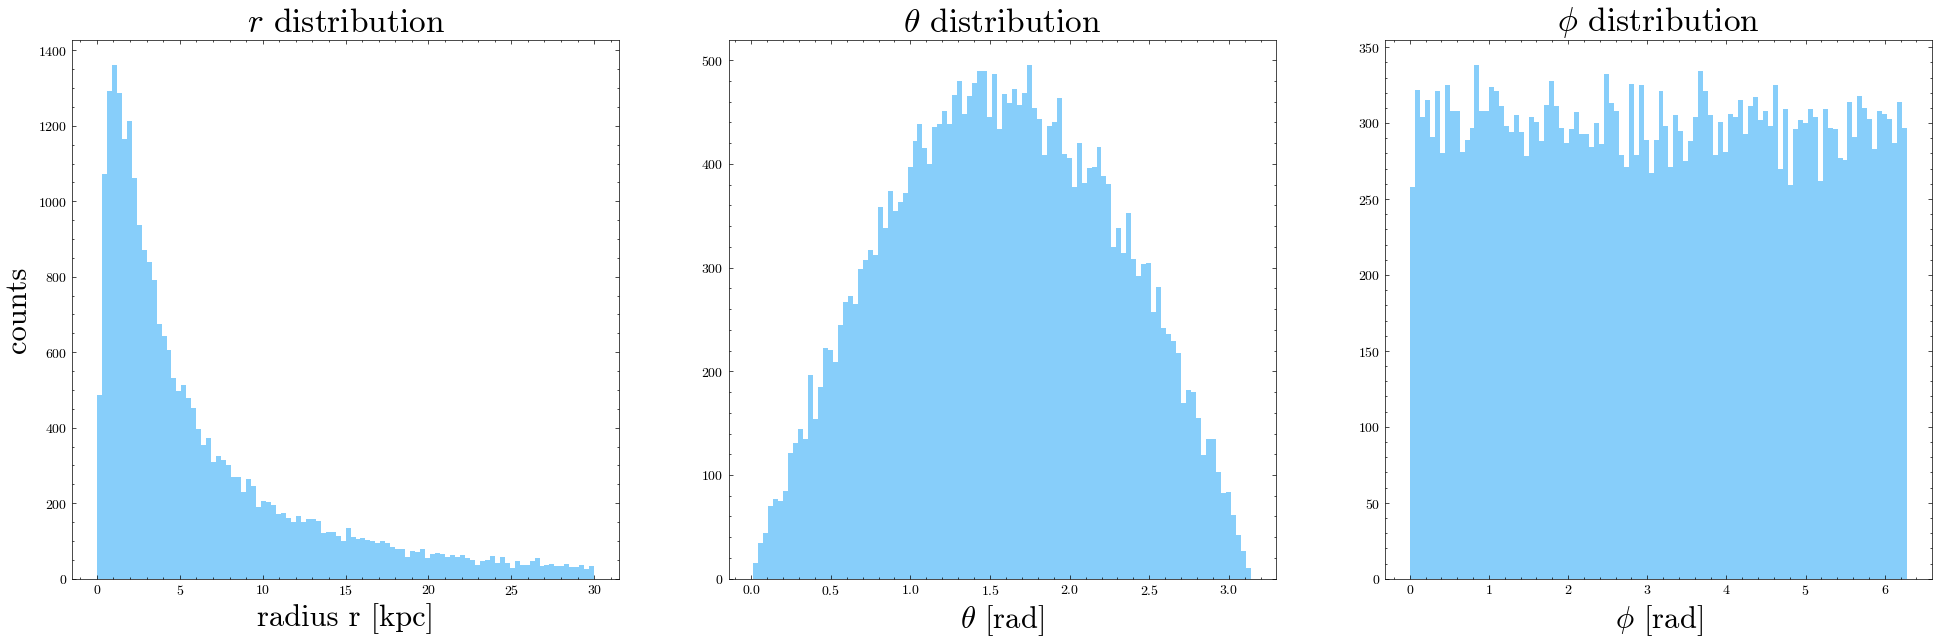

In [14]:
fig,ax = plt.subplots(ncols=3,nrows=1,figsize=(24,7))

ax[0].hist(radius_s, range=(0,30), bins = 100, color = 'lightskyblue')
ax[0].set_title('$r$ distribution', fontsize  = 24)
ax[0].set_ylabel("counts", fontsize  = 22)
ax[0].set_xlabel("radius r [kpc]", fontsize  = 22)

ax[1].hist(theta, bins = 100, color = 'lightskyblue')
ax[1].set_title(r'$\theta$ distribution', fontsize  = 24)
#ax[1].set_ylabel("counts", fontsize  = 22)
ax[1].set_xlabel(r'$\theta$ [rad]', fontsize  = 22)
ax[1].plot()

ax[2].hist(phi, bins = 100, color = 'lightskyblue')
ax[2].set_title('$\phi$ distribution', fontsize  = 24)
#ax[2].set_ylabel("counts", fontsize  = 22)
ax[2].set_xlabel("$\phi$ [rad]", fontsize  = 22)
ax[2].plot()

#plt.savefig('plots/positions_distrib.svg')
plt.show()

In [15]:
def pdf_r(r):
    return 2*a*r / (a+r)**3

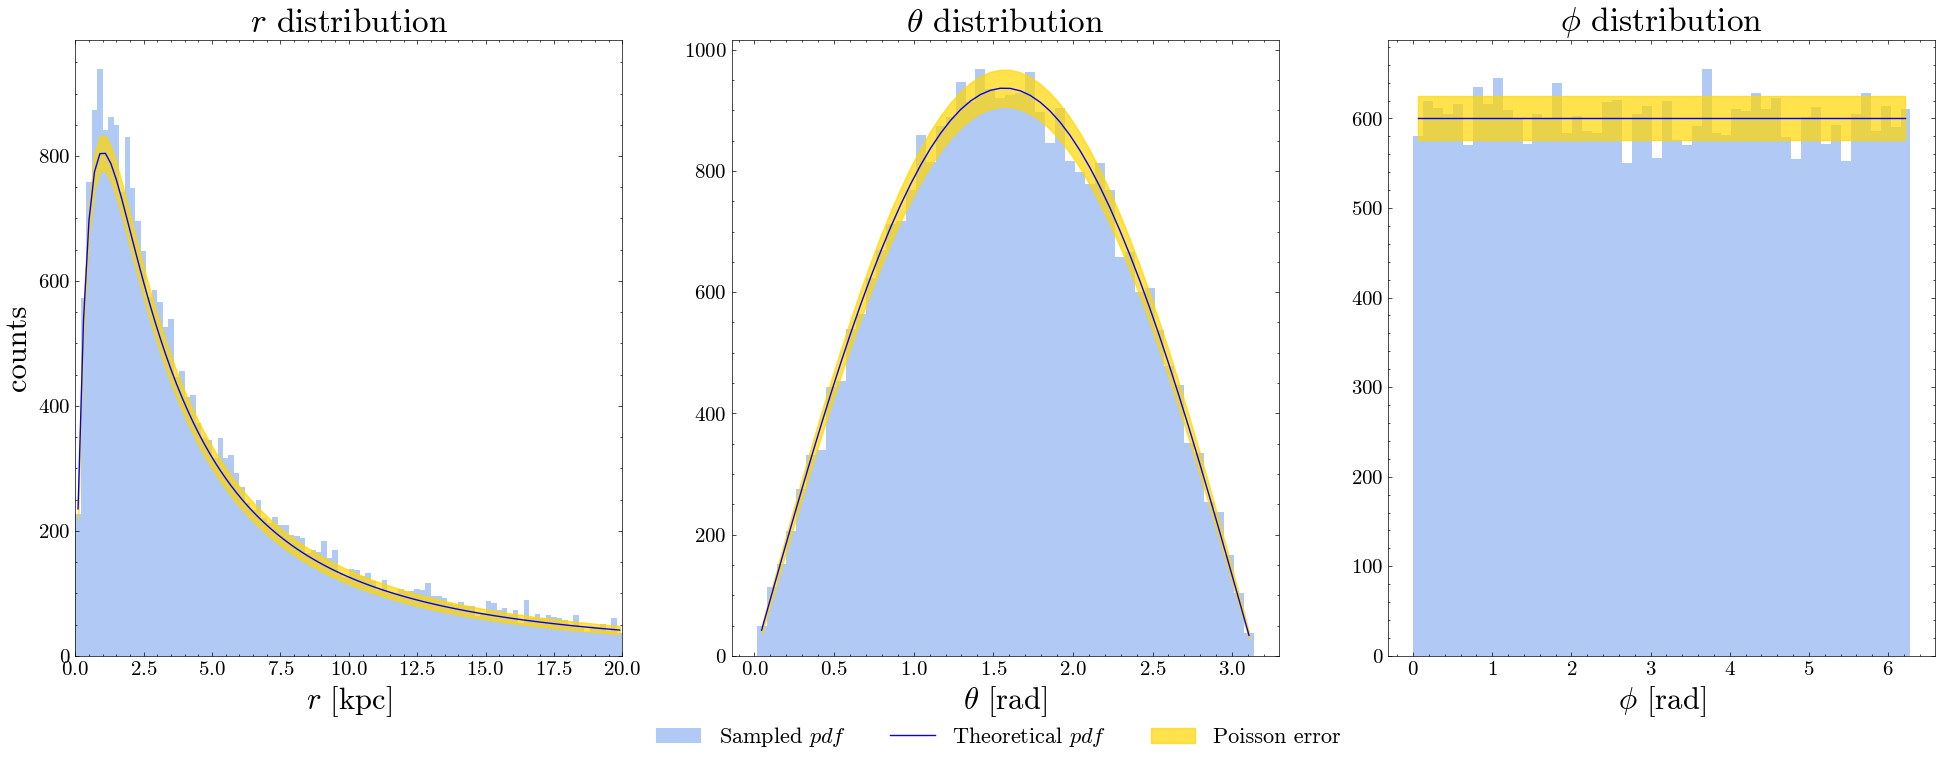

In [16]:
# analytical distributions: ----------------------------------------------------------------------------------
n_R, bins_R = np.histogram(radius,density=False,bins=100,range=(0,20))  # define the histo object
area_r = np.sum(n_R*np.diff(bins_R))  # compute the integral of the histogram
centers_r = bins_R[:-1] + 0.5*(bins_R[1]-bins_R[0])  # determine the centre of each bin
th_distr_R = pdf_r(centers_r)*area_r*1.1 # compute the theoretical distribution of radii from the pdf
err_r_th = np.sqrt(th_distr_R) # compute the analytical error

n_theta, bins_theta = np.histogram(theta, density=False,bins=50)
area_theta = np.sum(n_theta*np.diff(bins_theta))
centers_theta = bins_theta[:-1] + 0.5*(bins_theta[1]-bins_theta[0])
th_distr_theta = 1/2*(np.sin(centers_theta))*area_theta
err_theta_th = np.sqrt(th_distr_theta)

n_phi,bins_phi = np.histogram(phi,density=False,bins=50)
area_phi = np.sum(n_phi*np.diff(bins_phi))
centers_phi = bins_phi[:-1] + 0.5*(bins_phi[1]-bins_phi[0])
th_distr_phi = 1/(2*np.pi)*np.ones(len(bins_phi)-1)*area_phi
err_phi_th = np.sqrt(th_distr_phi)

# visualize the distributions: --------------------------------------------------------------------------------

# R distribution
fig,ax = plt.subplots(ncols=3,nrows=1,figsize=(24,8))
ax[0].hist(radius,density=False,bins=100,color='cornflowerblue',alpha=0.5,range=(0,20),label=r'Sampled $pdf$');
ax[0].set_xlim(0,20)
ax[0].set_title(r'$r$ distribution', fontsize  = 24)
ax[0].set_xlabel(r'$r$ [kpc]', fontsize  = 22)
ax[0].set_ylabel('counts', fontsize  = 22)
ax[0].plot(centers_r,th_distr_R,color='blue',label=r'Theoretical $pdf$')
ax[0].fill_between(centers_r,th_distr_R-err_r_th,th_distr_R+err_r_th,color='gold',alpha=0.7,label=r'Poisson error')
#ax[0].loglog()
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
ax[0].legend(loc = 'best', bbox_to_anchor=(2.35,-0.08), ncol=3, fontsize=16)

# Theta distribution
ax[1].hist(theta,density=False,bins=50,color='cornflowerblue',alpha=0.5);
ax[1].set_title(r'$\theta$ distribution', fontsize  = 24)
ax[1].set_xlabel(r'$\theta$ [rad]', fontsize  = 22)
ax[1].plot(centers_theta,th_distr_theta,color='blue')
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)
ax[1].fill_between(centers_theta,th_distr_theta-err_theta_th,th_distr_theta+err_theta_th,color='gold',alpha=0.7)

# Phi distribution
ax[2].hist(phi,density=False,bins=50,color='cornflowerblue',alpha=0.5);
ax[2].set_title(r'$\phi$ distribution', fontsize  = 24)
ax[2].set_xlabel(r'$\phi$ [rad]', fontsize  = 22)
ax[2].plot(centers_phi,th_distr_phi,color='blue')
ax[2].tick_params(axis='x', labelsize=15)
ax[2].tick_params(axis='y', labelsize=15)
ax[2].fill_between(centers_phi, th_distr_phi-err_phi_th,th_distr_phi+err_phi_th,color='gold',alpha=0.7)

#plt.savefig('plots/positions_distrib.png', dpi = 400)
plt.show()

In [17]:
#carthesian coord conversion -----------
def sph_to_carth (radius, theta, phi):
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    return x, y, z

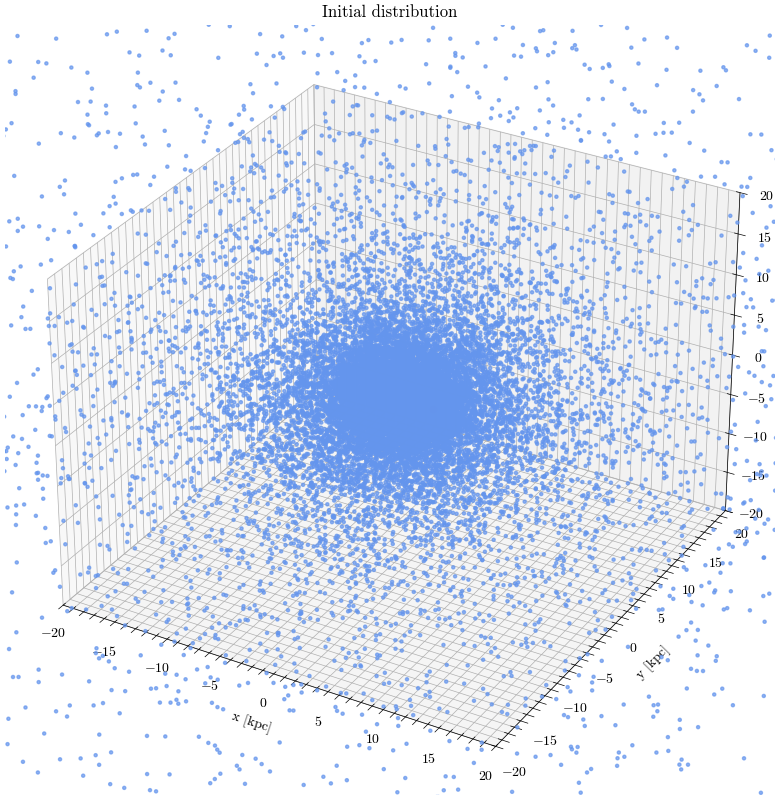

In [18]:
x, y, z = sph_to_carth(radius_s, theta, phi)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')

ax.scatter(x,y,z,s=5,alpha=0.7, color = 'cornflowerblue')
ax.scatter(x_1, y_1, z_1, color = 'r')
ax.set (title = 'Initial distribution', xlabel = 'x [kpc]', ylabel = 'y [kpc]', zlabel = 'z [kpc]', xlim = (-20,20), ylim = (-20, 20), zlim = (-20, 20))

plt.show()

## Density check

In [19]:
def compute_rho(radius):
    return M/(2*np.pi) * a/radius * 1/(radius+a)**3

In [20]:
def count_particles(radius, r_min, r_max):
    return int(np.sum((radius > r_min) & (radius < r_max)))

def numerical_density(radius, n_check):
    grid = np.geomspace(min(radius), max(radius), n_check)
    rho = []
    grid_centres = []
    rho_err = []
    
    for i in range(n_check - 1):
        dn = count_particles(radius, grid[i], grid[i+1]) 
        if dn > 10: #only taking bins with significant # of particles to reduce the error
            centre = 0.5 * (grid[i] + grid[i+1])
            dV = 4*np.pi/3 * (grid[i+1]**3 - grid[i]**3)
            rho.append((M/n) * (dn/dV))
            rho_err.append((M/n) * np.sqrt(dn) / dV) #poissonian error
            grid_centres.append(centre)
    return np.array(rho), np.array(grid_centres), np.array(rho_err)   

In [21]:
num_rho, rho_grid, rho_err = numerical_density(radius_s, 500)

analytical_rho = np.array([compute_rho(rg) for rg in rho_grid])

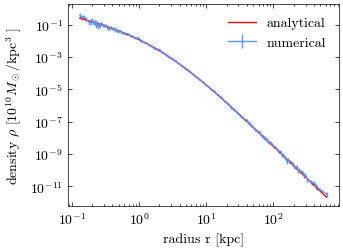

In [22]:
#fig = plt.figure(figsize = (10,10))
plt.errorbar(rho_grid, num_rho, yerr = rho_err, label ='numerical', c = 'cornflowerblue')
plt.plot(rho_grid, analytical_rho , c = 'r', label = 'analytical')
plt.xlabel('radius r [kpc]')
plt.ylabel(r'density $\rho$ [$10^{10} M_\odot / $kpc$^3$ ]')
plt.legend()
plt.loglog()
#plt.savefig('plots/density_H.png', dpi = 400)
plt.show()

### Checking if numerical and analytical density are coherent

In [23]:
from scipy import stats

Residuals mean = 0.0333, std = 0.9694.
Residuals coherent with Gaussian distrib. with pvalue = 0.8161.



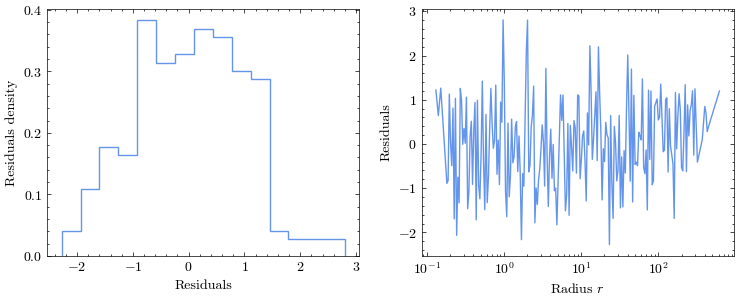

In [24]:
residuals = (num_rho - analytical_rho) / rho_err
chi2 = np.sum(residuals**2)

print(f'Residuals mean = {np.mean(residuals):.4f}, std = {np.std(residuals):.4f}.') #coherent with Gaussian if mean = 0, std = 1
D, pvalue = stats.kstest(residuals, 'norm')
print(f'Residuals coherent with Gaussian distrib. with pvalue = {pvalue:.4f}.\n') #accept if pvalue > 0.05

fig, ax = plt.subplots(ncols = 2, figsize = (7.5, 3))
fig.tight_layout()
plt.subplots_adjust(wspace=0.2)

ax[0].hist(residuals, bins = 15, density = True, histtype = 'step', color = 'cornflowerblue')
ax[0].set_xlabel('Residuals')
ax[0].set_ylabel('Residuals density')

ax[1].plot(rho_grid, residuals, color = 'cornflowerblue')
ax[1].set_ylabel('Residuals')
ax[1].set_xlabel(r'Radius $r$')
ax[1].semilogx()
plt.show()

In [25]:
dof = len(residuals) #just equal to # of bins since we have not used data to infer parameters
chi2_dof = chi2 / dof

p_value = stats.chi2.sf(chi2, dof) #chi2.survival_function: integral of chi2 between our chi2_dof value and +inf

print(f"chi2 = {chi2:.3f}")
print(f"dof = {len(residuals)}")
print(f"reduced chi2 = {chi2 / len(residuals):.3f}")
print(f"p-value = {p_value}") #accept if above 0.05

chi2 = 203.203
dof = 216
reduced chi2 = 0.941
p-value = 0.7244277065907967


## Velocity sampling

In [26]:
def compute_potential(radius):
    return - M / (radius + a)
    
def distribution_function(eps):
    v_g = np.sqrt(M/a)
    factor_1 = M/(8 * np.sqrt(2) * np.pi**3 * a**3 * v_g**3)
    factor_2 = 1 / (1-eps**2)**(5/2)
    term_1 = (3 * np.arcsin(eps))
    term_2 = eps * np.sqrt(1-eps**2) * (1-2*eps**2) * (8*eps**4 - 8*eps**2 - 3)

    return factor_1 * factor_2 * (term_1 + term_2)
    
def v_escape(radius):
    return np.sqrt(- 2 * compute_potential(radius))

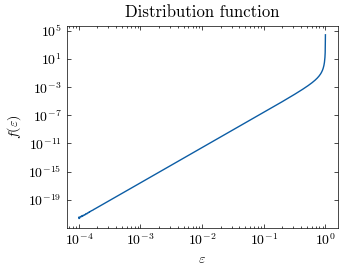

In [27]:

eps_values = np.geomspace(0.0001, 0.999, 1000)
f_values = distribution_function(eps_values)

norm = np.trapezoid(f_values, eps_values)

plt.plot(eps_values, f_values)
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.title('Distribution function')
plt.loglog()
plt.show()

In [28]:
print(f_values[f_values<0])

[]


In [29]:
print(norm)

122.89288054215112


In [30]:
def df_norm(eps):
    eps = np.sqrt(- eps / compute_potential(0) )
    return distribution_function(eps)/norm

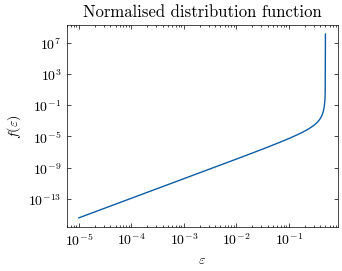

In [31]:
eps_values = np.geomspace(0.00001, - 0.99999 * compute_potential(0), 1000)
f_values = df_norm(eps_values)

plt.plot(eps_values, f_values)
plt.xlabel(r'$\varepsilon$')
plt.ylabel(r'$f(\varepsilon)$')
plt.title('Normalised distribution function')
plt.loglog()
plt.show()

In [32]:
from tqdm import tqdm

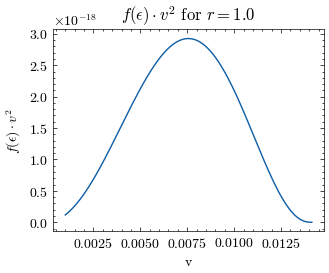

In [33]:
r=1E+4
phi_r = compute_potential(r)
v_max = v_escape(r)

v_vals = np.linspace(0.001, v_max, 500)
epsilon_vals = -(0.5 * v_vals**2 + phi_r)
f_v = df_norm(epsilon_vals) * v_vals**2

plt.plot(v_vals, f_v)
plt.xlabel("v")
plt.ylabel(r"$f(\epsilon) \cdot v^2$")
plt.title(r"$f(\epsilon) \cdot v^2$ for $r=1.0$")
plt.show()

In [34]:
def find_pmax(radius):
    v_values = np.linspace(0.001, v_escape(radius), 500)
    eps_v = -(compute_potential(radius) + 0.5* v_values**2)
    f_eps_v = df_norm(eps_v) * v_values**2

    return max(f_eps_v)

In [35]:
def sample_vel(radius, plot):
    v_rej = []
    p_rej = []
    while True:
        v_try = np.random.uniform(0, v_escape(radius))
        eps_try = - (compute_potential(radius) + 0.5*v_try**2)
        
        if eps_try <= 0 or eps_try >= 1: 
            print('error: epsilon out of bounds.')
            continue

        p_v = df_norm(eps_try) * v_try**2
        p_max = find_pmax(radius)

        p_try = np.random.uniform(0, p_max)

        if p_try >= p_v: 
            v_rej.append(v_try)
            p_rej.append(p_try)
        if p_try < p_v: 
            if plot: 
                xx = np.linspace(0, v_escape(radius), 200)
                plt.plot(xx, df_norm(- (compute_potential(radius) + 0.5*xx**2)) * xx**2)
                plt.scatter(v_rej, p_rej, c = 'r', s=5)
                plt.scatter(v_try, p_try, s=5)
            return v_try

/tmp/ipykernel_4647/1905069767.py:2: RuntimeWarning: invalid value encountered in sqrt        | 0/30000 [00:00<?, ?it/s]
  eps = np.sqrt(- eps / compute_potential(0) )
100%|███████████████████████████████████████████████████████████████████████████| 30000/30000 [00:04<00:00, 6970.13it/s]


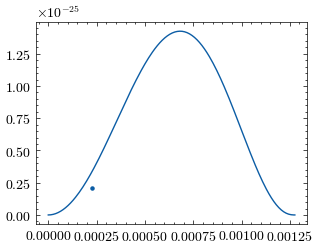

In [36]:
v_particles = np.zeros(n)

for i in tqdm(range(n)):
    v_particles[i] = sample_vel(radius_s[i], False)
    if i == n-1:     v_particles[i] = sample_vel(radius_s[i], True)
    

In [37]:
print(max(v_particles))

0.8772559840113305


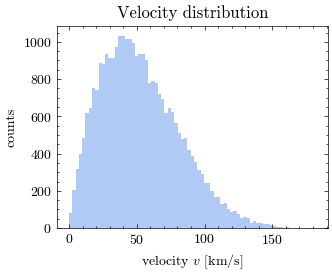

In [38]:
plt.figure()
plt.hist(v_particles * v_conver * u.km/u.cm / 100000,  bins = 75, color='cornflowerblue',alpha=0.5) 
plt.xlabel("velocity $v$ [km/s]")
plt.ylabel("counts")
plt.title("Velocity distribution")
#plt.savefig('plots/v_modulus.png', dpi = 400)
plt.show()

In [39]:
eps_particles = - (compute_potential(radius_s) + 0.5*v_particles**2)
print(min(eps_particles))

7.881315333655623e-07


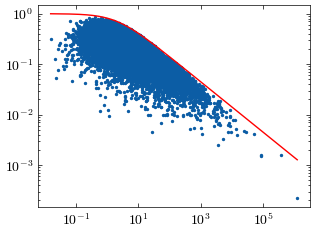

In [40]:
plt.plot(radius_s, np.sqrt(- 2 * compute_potential(radius_s)), c = 'r')
plt.scatter(radius_s, v_particles, s = 2)
plt.loglog()
plt.show()

In [41]:
P_theta_v = np.random.uniform(0, 1, n)
theta_v = np.arccos(1 - 2*P_theta_v)

P_phi_v = np.random.uniform(0, 1, n)
phi_v = 2 * np.pi * P_phi_v

vx, vy, vz = sph_to_carth (v_particles, theta_v, phi_v)

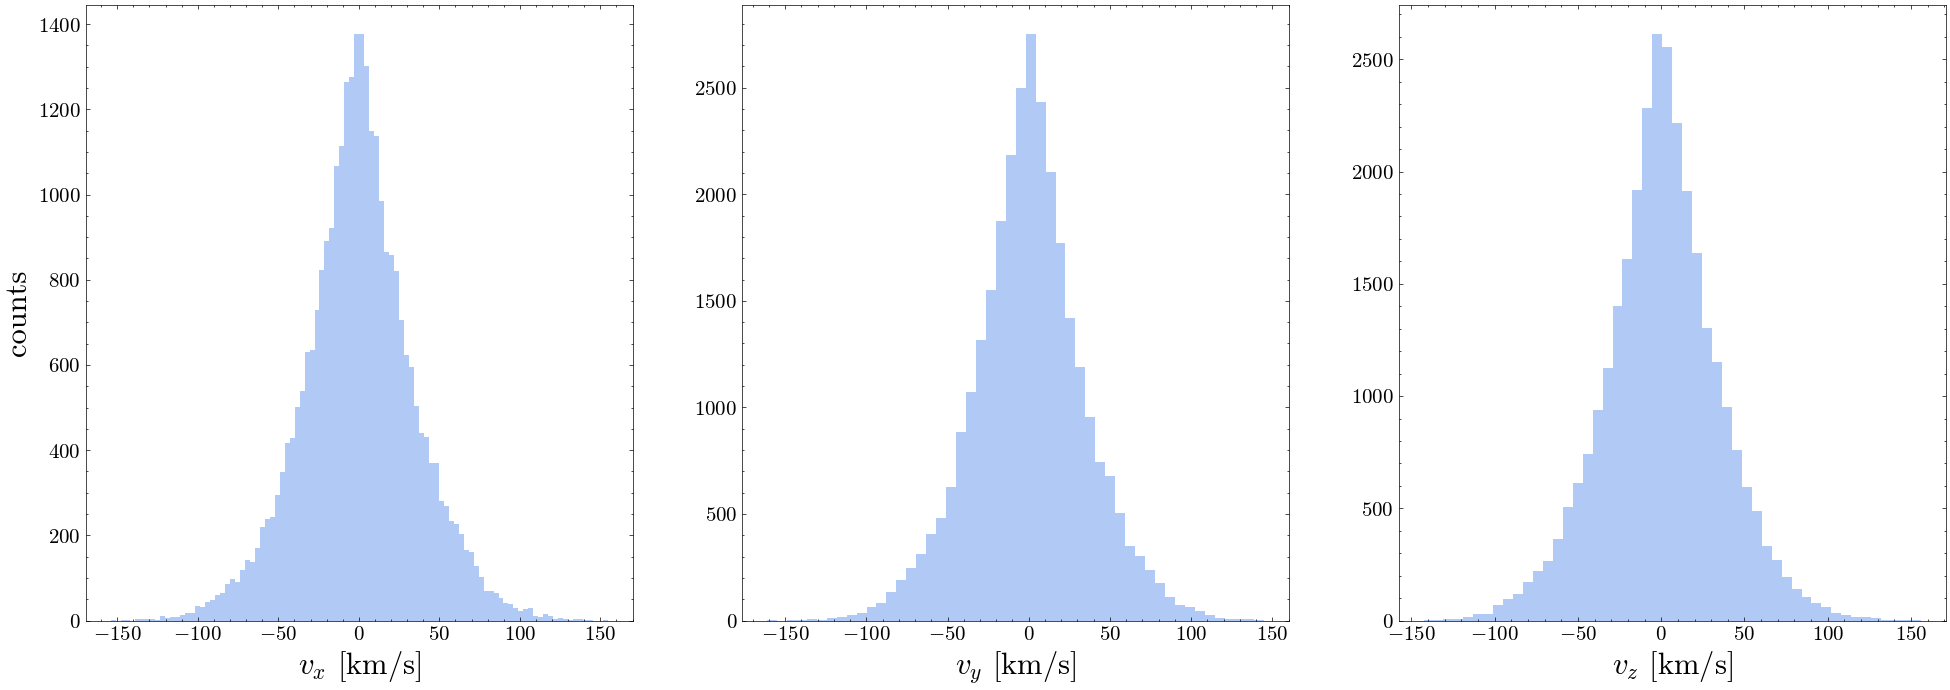

In [42]:
fig,ax = plt.subplots(ncols=3,nrows=1,figsize=(24,8))
ax[0].hist(vx* v_conver * u.km/u.cm / 100000,density=False,bins=100,color='cornflowerblue',alpha=0.5,label=r'Sampled $pdf$')
ax[0].set_xlabel(r'$v_x$ [km/s]', fontsize  = 22)
ax[0].set_ylabel('counts', fontsize  = 22)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)

# Theta distribution
ax[1].hist(vy* v_conver * u.km/u.cm / 100000,density=False,bins=50,color='cornflowerblue',alpha=0.5)
ax[1].set_xlabel(r'$v_y$ [km/s]', fontsize  = 22)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

# Phi distribution
ax[2].hist(vz* v_conver * u.km/u.cm / 100000,density=False,bins=50,color='cornflowerblue',alpha=0.5)
ax[2].set_xlabel(r'$v_z$ [km/s]', fontsize  = 22)
ax[2].tick_params(axis='x', labelsize=15)
ax[2].tick_params(axis='y', labelsize=15)

#plt.savefig('plots/vel_distrib.png', dpi = 400)
plt.show()

In [43]:
import datetime

def get_timestamp_filename():
    now = datetime.datetime.now()
    timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
    return f"H_input_{timestamp}.txt"

In [44]:
filename = get_timestamp_filename()
print(filename)

H_input_2025-10-01_16-22-44.txt


In [45]:
inputf = open(filename, 'w')

particles_masses = str(M_BH_1) + '\n'
particles_positions = str(x_1) + ' ' + str(y_1) + ' ' + str(z_1) + '\n'
particles_velocities = str(v_x1) + ' ' + str(v_y1) + ' ' + str(v_z1) + '\n'

for i in range(n):
    particles_masses = particles_masses + str(M/n) + '\n'
    particles_positions = particles_positions + str(x[i]) + ' ' + str(y[i]) + ' ' + str(z[i]) + '\n'
    particles_velocities = particles_velocities +  str(vx[i]) + ' ' + str(vy[i]) + ' ' + str(vz[i]) + '\n'

lines = [str(n+1) + '\n' + str(n_dim) + '\n0\n' + particles_masses + particles_positions + particles_velocities]
inputf.writelines(lines)

inputf.close()

In [46]:
sigma2 = M / (12 * a)
sigma = np.sqrt(sigma2)
print("Dispersione di velocità sigma =", sigma, "IU")

#raggio di influenza
def r_influence(M_BH):
    return M_BH / (sigma**2)

r_inf = r_influence (M_BH_1)
softening = 0.5 * r_inf

print('suggested softening parameter = ', softening)

Dispersione di velocità sigma = 0.2041241452319315 IU
suggested softening parameter =  0.12000000000000001


In [47]:
day = str(datetime.datetime.now().day)
month = str(datetime.datetime.now().month)

In [48]:
folder = '../stellar_systems_dynamics2024/final_exercise/runs/' + day + '_' + month + '/'
outname=filename.replace('input', 'output')
logname=filename.replace('input', 'log')

In [49]:
alpha = 100
dtime = (1 / alpha) * (2 * np.pi * r_1 / v_circ(r_1))
tstop = 500
dtout = dtime

In [50]:
command_line = ('./treecode in=' + folder + filename + ' out=' + folder + outname + 
                ' dtime=' + str(dtime) + ' eps=' + str(softening) + ' theta=0.5 tstop=' + str(tstop) + ' dtout=' + str(dtout) + ' > ' + folder + logname)

In [51]:
print(command_line)

./treecode in=../stellar_systems_dynamics2024/final_exercise/runs/1_10/H_input_2025-10-01_16-22-44.txt out=../stellar_systems_dynamics2024/final_exercise/runs/1_10/H_output_2025-10-01_16-22-44.txt dtime=0.5441398092702654 eps=0.12000000000000001 theta=0.5 tstop=500 dtout=0.5441398092702654 > ../stellar_systems_dynamics2024/final_exercise/runs/1_10/H_log_2025-10-01_16-22-44.txt


In [52]:
cmdname = filename.replace('input', 'cmd')

In [53]:
inputf = open(cmdname, 'w')

inputf.writelines(command_line)

inputf.close()

Virial radius = 200 * rho_c

In [54]:
crit_rho = 9E-30 *u.g/(u.cm)**3 #g / cm3
rho_200 = 200 * crit_rho * (M_I / M_P) / (R_I/R_P)**3
eps_rho = rho_200 / 10

rho_200

<Quantity 2.65961167e-06 solMass / kpc3>

for i in range(len(rho_grid)):
    if (rho_200 - eps_rho )*(u.kpc**3 / u.solMass) <= analytical_rho[i] <= (rho_200 + eps_rho )*(u.kpc**3 / u.solMass): print(rho_grid[i], compute_rho(rho_grid[i]))

### Dynamical Friction Timescale

The time it takes the perturber to reach the centre is dominated by the distribution potential, while dynamical friction is only a correction. We asssume that at each time the velocity of the perturber is the circular one (v_circ(radius)).

$$\frac{dv_M}{dt} = -16 \pi^2 m (M + m) \mathrm{ln}(\Lambda) \frac{\overline{v}_M}{|v_M|^3} \cdot \int_0^{v_M} f(v_m)v_m^2 dv_m $$

where $f(v_m)$ is our distribution function, which takes epsilon as input: at each radius, the potential is fixed and we need to integrate over all the possible velocities, which are between 0 and v_circ.

ln($\Lambda$)) is the Coulomb logarithm, originally defined as ln($\Lambda$)) = ln($\frac{b\mathrm{max}}{b\mathrm{min}}$) where $b_\mathrm{max}$ is in principle the radius of the distribution. We will choose b_max as the radius of the perturber and b_min as the softening of the system.

To get an estimate of the timescale from the acceleration, we use:

$$t_{df} \simeq \int_{r_{min }}^{r_{max}} \frac{v_{circ}}{|a_{df}| \cdot r} dr$$


In [55]:
def dyn_friction_accel (M, m, radius, softening): #Internal Units only
    norm = - 16 * np.pi**2 * (M + m) * m
    v_M = v_circ(radius)
    v_term = 1 / v_M**2

    Coulomb_l = np.log(radius_s[-1] / softening)
    
    v_space = np.linspace(0, v_M, 500)
    eps = - (compute_potential(radius) + 0.5*v_space**2)

    integral = np.trapezoid(df_norm(eps) * v_space**2, v_space)

    return norm * Coulomb_l * v_term * integral

def dyn_friction_timescale(M, m, radius_max, radius_min, softening):
    radii = np.linspace(radius_min, radius_max, 500)
    accel = np.array( [np.abs(dyn_friction_accel(M, m, r, softening)) for r in radii] )
    if 0 in accel: print('error, found acc = 0 at radius = ', radii[np.where(accel == 0)[0]])
    integrand = v_circ(radii) / (np.abs(accel) * radii)
    plt.plot(radii, integrand)
    plt.xlabel("Radius")
    plt.ylabel("Integrand (1/time)")
    plt.title("Dynamical Friction Integrand")
    return np.trapezoid(integrand, radii)

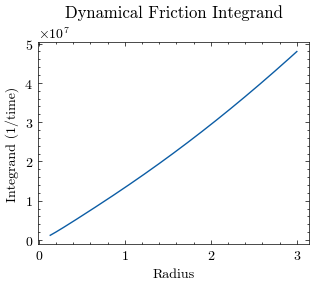

In [56]:
df_time = dyn_friction_timescale(M_BH_1, M/n, r_1, 1.1 * softening, softening)
df_time_IU = df_time * t_I
df_time_P = time_conv * df_time_IU

In [57]:
softening

np.float64(0.12000000000000001)

In [58]:
df_time_IU

<Quantity 65797453.06450683 kpc(3/2) / solMass(1/2)>

In [59]:
df_time_P.to(u.Myr)

<Quantity 3.10223802e+08 Myr>